Incase of any error in this file, please tag `@23f2000573` in discourse

# Import Libraries

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Dataset

In [9]:
from sklearn.datasets import fetch_lfw_people

`img` is an object

`images` is an attribute of the object `img`

`img.images` is a numpy array of shape `(n,r,c)`

`n` images

`r` rows for each image

`c` columns for each image

In [10]:
img=fetch_lfw_people()

In [11]:
img.images.shape

(13233, 62, 47)

In [12]:
img.images[0].shape

(62, 47)

every pixel in an image is encoded with a number from $0$ to $1$

every pixel is an element in a matrix(image)

depending on the value of the pixel, a colour is shown while runnig `plt.imshow(img.image[0],cmap='gray')`

In [13]:
print(img.images[0])

[[0.17124183 0.14901961 0.12287582 ... 0.1124183  0.13986929 0.15947713]
 [0.18692811 0.16470589 0.12810458 ... 0.12156863 0.14248367 0.1633987 ]
 [0.16732027 0.15686275 0.19607843 ... 0.12810458 0.14771242 0.18300654]
 ...
 [0.703268   0.3882353  0.17908497 ... 0.07712419 0.09803922 0.08496732]
 [0.2653595  0.16732027 0.15294118 ... 0.09281046 0.10588235 0.09542484]
 [0.14379086 0.14901961 0.14117648 ... 0.09673203 0.09934641 0.09411765]]


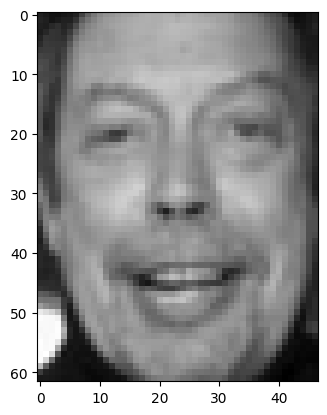

In [14]:
plt.imshow(img.images[0],cmap='gray')

# RE-INITIALIZATION OF `img`

We would like to have more pixels to get better picture quality.

`resize` parameter is set to `4`. If it is set below $1$, then the number of pixels will reduce. More than $1$ will increase it.

Resize will take some time. We don't want to resize every image(13233). It will take a lot of time. Therefore, we will select the images of individuals with greater than or equal to than 400 images in this dataset.

In [15]:
img=fetch_lfw_people(min_faces_per_person=400,resize=4)

In [16]:
img.images.shape

(530, 500, 376)

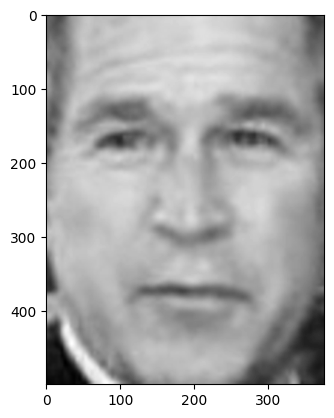

In [17]:
plt.imshow(img.images[0],cmap='gray')

In [18]:
#EXAMPLE
a=np.array([[1,2,3],[4,5,6]])
a=a.reshape(2*3)
a

array([1, 2, 3, 4, 5, 6])

In [19]:
#EXAMPLE
a.reshape(2,3)

array([[1, 2, 3],
       [4, 5, 6]])

In [20]:
# We Will Run PCA on 100 images only. Therefore, we wil sample the indices
indices=np.random.randint(0,530,size=100)
indices

array([ 20,  83, 152, 241, 411, 198, 102, 429, 329,  13, 309, 469,  97,
       104, 212, 107, 151,  64, 352, 485, 204, 249, 349, 141, 477,  34,
        99, 428, 249, 446, 447,  11, 163, 519, 228,  25, 261, 230, 179,
       443, 198, 487, 444, 319, 336,  48, 266, 235, 105, 386,  66, 366,
         8, 301, 420, 107,  92, 523, 443, 286, 383, 411, 115, 323, 403,
       125, 153, 477, 303, 288,  28, 476, 426,  29,  72,  61, 379,  40,
       126, 231, 493, 293,  57, 440, 109, 140, 203,  49,   7, 222,  52,
       470, 366, 513, 403, 375, 331, 126,   9, 449])

In [21]:
dataset=img.images[indices]

In [22]:
dataset.shape

(100, 500, 376)

In [23]:
# Every image is a matrix. Reshape every image to a vector.
# 500 rows and 376 columns. After reshaping, we get a vector of 500*376=188000 features. Now, there are 100 images and every image is a vector
V=dataset.reshape(100,500*376)
V.shape

(100, 188000)

In [26]:
mu=V.mean(axis=0)
mu.shape
#mu->average of every image
#every row vector is an image
#mu-->mean of row vectorsaxis=0

(188000,)

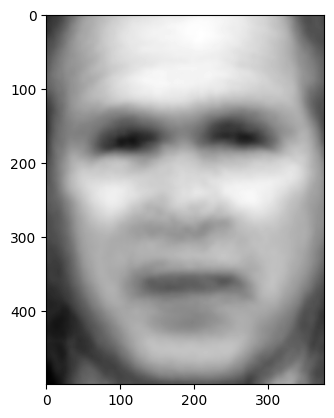

In [28]:
# visualize the mean, but we have to reshape it to a matrixe
plt.imshow(mu.reshape(500,376),cmap='gray')

In [29]:
#centering the dataset
X=V-mu
X.shape

(100, 188000)

In [30]:
# Now, every column is an image
X=X.T
X.shape
#dxn

(188000, 100)

In [31]:
# Find X transpose X
# it is a nxn matrix
K=X.T@X
K.shape

(100, 100)

In [33]:
# read the docstring of this function
np.linalg.eigh?

In [34]:
#acending order
eval,evec=np.linalg.eigh(K)

In [35]:
#some eigenvectors are so-small, close to 0. But, the calculation is giving a few negative values.
eval

array([-4.8558064e-05, -1.7800219e-05, -2.1355338e-06, -1.2549204e-07,
        7.9394141e-13,  4.8052252e-12,  1.0493483e-05,  3.4511024e-05,
        4.9721537e-04,  1.3349667e-03,  1.7361496e+02,  2.1545393e+02,
        2.2897415e+02,  2.3884634e+02,  2.4477353e+02,  2.6470221e+02,
        2.7059317e+02,  2.8836102e+02,  3.0740509e+02,  3.1755746e+02,
        3.3499777e+02,  3.4483554e+02,  3.6399557e+02,  3.7792026e+02,
        4.0048663e+02,  4.0068982e+02,  4.1717209e+02,  4.2049820e+02,
        4.2794275e+02,  4.4076807e+02,  4.5987665e+02,  4.8606982e+02,
        5.2080432e+02,  5.2585504e+02,  5.3619495e+02,  5.5389087e+02,
        5.6803210e+02,  5.8017932e+02,  6.2249036e+02,  6.3572162e+02,
        6.5743964e+02,  6.6156653e+02,  6.9679376e+02,  7.1104907e+02,
        7.2221295e+02,  7.5620801e+02,  7.7322217e+02,  8.1519275e+02,
        8.3539087e+02,  8.7860675e+02,  9.0203302e+02,  9.3357587e+02,
        9.8592291e+02,  1.0388198e+03,  1.0652245e+03,  1.0999463e+03,
      

In [36]:
#some eigenvectors are so-small, close to 0. But, the calculation is giving a few negative values.
#As of now, lets us use abs() function to make them posivtive. They are very small. So, shouldn't make much difference
for i in range(100):
  if(eval[i]<0):
    eval[i]=abs(eval[i])
eval

array([4.8558064e-05, 1.7800219e-05, 2.1355338e-06, 1.2549204e-07,
       7.9394141e-13, 4.8052252e-12, 1.0493483e-05, 3.4511024e-05,
       4.9721537e-04, 1.3349667e-03, 1.7361496e+02, 2.1545393e+02,
       2.2897415e+02, 2.3884634e+02, 2.4477353e+02, 2.6470221e+02,
       2.7059317e+02, 2.8836102e+02, 3.0740509e+02, 3.1755746e+02,
       3.3499777e+02, 3.4483554e+02, 3.6399557e+02, 3.7792026e+02,
       4.0048663e+02, 4.0068982e+02, 4.1717209e+02, 4.2049820e+02,
       4.2794275e+02, 4.4076807e+02, 4.5987665e+02, 4.8606982e+02,
       5.2080432e+02, 5.2585504e+02, 5.3619495e+02, 5.5389087e+02,
       5.6803210e+02, 5.8017932e+02, 6.2249036e+02, 6.3572162e+02,
       6.5743964e+02, 6.6156653e+02, 6.9679376e+02, 7.1104907e+02,
       7.2221295e+02, 7.5620801e+02, 7.7322217e+02, 8.1519275e+02,
       8.3539087e+02, 8.7860675e+02, 9.0203302e+02, 9.3357587e+02,
       9.8592291e+02, 1.0388198e+03, 1.0652245e+03, 1.0999463e+03,
       1.1438156e+03, 1.1665474e+03, 1.2497260e+03, 1.2566549e

In [37]:
print(eval.shape)
print(evec.shape)

(100,)
(100, 100)


In [38]:
# EXAMPLE
a=np.array([1,2,3])
a=np.flip(a)
a

array([3, 2, 1])

In [39]:
b=[[1,2,3],[4,5,6]]
b=np.flip(b,axis=1)
b

array([[3, 2, 1],
       [6, 5, 4]])

In [40]:
# Use this to have the eigenvalues in descending order
# If we flip twice, it will once agan become in ascending order
eval=np.flip(eval)

In [41]:
# Flip the evec so that it corresponds to the flip of eval
evec=np.flip(evec,axis=1)
evec.shape

(100, 100)

In [42]:
# Find alpha matrix (refer to lecture)
alpha=np.array([evec[:,i]/(np.sqrt(100*eval[i])) for i in range(100)])

In [43]:
alpha.shape

(100, 100)

In [44]:
# every column of pcs is an eigenvector of covariance matrix.
pcs=X@alpha
pcs.shape

(188000, 100)

In [45]:
#example
a=np.array([2,4,6])
a/2

array([1., 2., 3.])

In [46]:
# to get eigenvalue of covariance matrix
var=eval/100

In [47]:
#example
list(enumerate([5,6,7,8,9]))

[(0, 5), (1, 6), (2, 7), (3, 8), (4, 9)]

In [48]:
# enumerating to have a scatter plot
sct=list(enumerate(var))
sct

[(0, 876.3968),
 (1, 635.1991),
 (2, 322.54327),
 (3, 252.96385),
 (4, 185.36163),
 (5, 134.14995),
 (6, 126.655754),
 (7, 114.406),
 (8, 93.59251),
 (9, 86.284454),
 (10, 78.342155),
 (11, 67.104065),
 (12, 59.31816),
 (13, 57.302807),
 (14, 54.206985),
 (15, 48.747906),
 (16, 44.828747),
 (17, 39.286465),
 (18, 36.62759),
 (19, 32.054287),
 (20, 30.959671),
 (21, 30.009544),
 (22, 28.9222),
 (23, 27.664673),
 (24, 26.757378),
 (25, 25.668528),
 (26, 23.516665),
 (27, 21.723364),
 (28, 21.15537),
 (29, 20.725655),
 (30, 18.500208),
 (31, 17.35506),
 (32, 17.077679),
 (33, 16.590225),
 (34, 16.121624),
 (35, 15.13902),
 (36, 14.509246),
 (37, 14.136937),
 (38, 13.604209),
 (39, 13.38469),
 (40, 12.566549),
 (41, 12.497259),
 (42, 11.665474),
 (43, 11.438155),
 (44, 10.999463),
 (45, 10.652245),
 (46, 10.388198),
 (47, 9.859229),
 (48, 9.335758),
 (49, 9.02033),
 (50, 8.786068),
 (51, 8.353909),
 (52, 8.151928),
 (53, 7.7322216),
 (54, 7.56208),
 (55, 7.2221293),
 (56, 7.110491),
 (57, 

In [49]:
sct=np.array(sct)
sct.shape
#[index,value]
#

(100, 2)

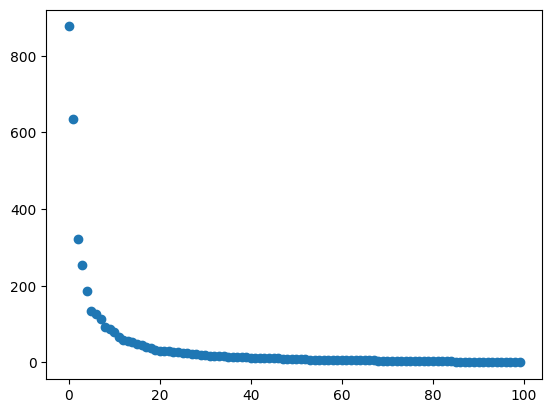

In [50]:
plt.scatter(sct[:,0],sct[:,1])

In [51]:
#reconstruct with first q pcs
q=10
W=pcs[:,:q]
W.shape

(188000, 10)

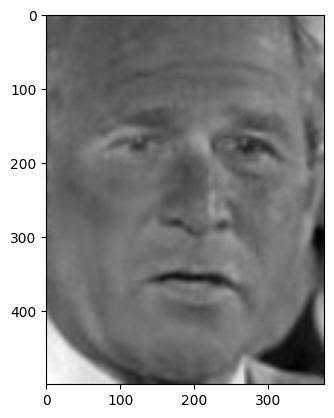

In [52]:
img_1=X[:,55]
img_1.shape
plt.imshow(img_1.reshape(500,376),cmap='gray')

In [53]:
# we can reconstruct the image using (W@W.T@img_1)
# no of operations for W@W.T@img_1 is very huge
# first find (W.T@img_1)
temp=W.T@img_1

In [54]:
rec_1=W@temp
rec_1.shape

(188000,)

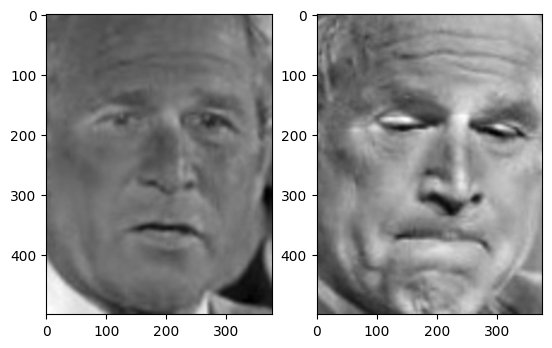

In [55]:
plt.subplot(1,2,1)
plt.imshow(img_1.reshape(500,376),cmap='gray')
plt.subplot(1,2,2)
plt.imshow(rec_1.reshape(500,376),cmap='gray')

#try other images and reconstruct with some more pcs and with less pcs
#if we have a lot of images, the reconstruction could be better (probably)
#Try to do the same with the default pixels